# 1. BACKGROUND OF STUDY

Student dropout is a major challenge facing higher education institutions globally, and Nigerian universities are no exception. Every academic session, a significant number of students discontinue their studies due to various factors such as financial difficulties, poor academic performance, lack of support systems, and personal issues.

This problem not only affects the students involved but also has broader implications on national development, as it leads to a waste of educational resources and reduces the number of skilled graduates entering the workforce.

With the advancement of Machine Learning, it is now possible to analyze historical student data and identify patterns that indicate whether a student is at risk of dropping out. Predictive models can assist universities in early identification of such students, allowing timely intervention strategies to improve retention rates.

This project focuses on developing machine learning models to predict student dropout in universities using academic, demographic, and socio-economic data. Multiple models will be trained and evaluated to determine the most effective approach for this prediction task.

# 2. DATA PREPROCESSING SECTION

### Import librariess

In [1]:
import pandas as pd                              # tabular data handling
import numpy as np                               # numerical arrays
import joblib                                    # save/load trained models to disk
import matplotlib.pyplot as plt                  # plotting
import seaborn as sns                            # nicer statistical plots
 
# Model selection utilities: splitting data and cross-validation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
 
# Preprocessing: feature scaling
from sklearn.preprocessing import StandardScaler
 
# Feature selection via mutual information
from sklearn.feature_selection import mutual_info_classif
 
# The three classifiers we will compare (one from each algorithm family)
from sklearn.linear_model import LogisticRegression   # linear model
from sklearn.ensemble import RandomForestClassifier   # tree ensemble
from sklearn.svm import SVC                            # kernel-based margin classifier
 
# Evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
 

In [4]:
# random seed so results are reproducible 
RANDOM_STATE = 42
sns.set_style("whitegrid") # global plot style

### Load Dataset

In [5]:
df = pd.read_csv(r"C:\Users\HomePC\Desktop\my_Desktop\500L\project\dataset\dataset.csv")

In [6]:
df.columns = df.columns.str.strip().str.replace('\ufeff', '')

In [7]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### Inspecting dataset

In [8]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(4424, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation           

As seen above, the dataset does not have missing values.

# 3. DATA CLEANING

In [9]:
# Strip whitespace and remove the byte-order-mark (\ufeff) some CSVs include
df.columns = df.columns.str.strip().str.replace('\ufeff', '')
print(f"Raw shape: {df.shape}")

Raw shape: (4424, 35)


In [10]:
# Remove duplicate rows and any rows with missing values, then reset the index
df = df.drop_duplicates().dropna().reset_index(drop=True)

In [11]:
# Keep only the two target classes we care about (drop "Enrolled" if present)
df = df[df['Target'].isin(['Dropout', 'Graduate'])].copy()

In [12]:

# Encode the target as binary: 1 = Dropout (positive class), 0 = Graduate
df['Target'] = (df['Target'] == 'Dropout').astype(int)

In [13]:
# Outlier trimming on age: keep the middle 98% (drop top/bottom 1%)
# This reduces the influence of extreme values on scaling and model fitting.
q_lo, q_hi = df['Age at enrollment'].quantile([0.01, 0.99])
df = df[(df['Age at enrollment'] >= q_lo) & (df['Age at enrollment'] <= q_hi)]
print(f"After cleaning: {df.shape}")
print(f"Class balance:\n{df['Target'].value_counts()}")

After cleaning: (3593, 35)
Class balance:
Target
0    2189
1    1404
Name: count, dtype: int64


In [14]:

# Separate predictors (X) from the target (y)
X = df.drop(columns=['Target'])
y = df['Target']

# 4. FEATURES SELECTION

In [15]:
# Drop constant columns: a feature with only one unique value carries no information
X = X.loc[:, X.nunique() > 1]

In [16]:
# Compute mutual information between each feature and the target
# Higher MI => the feature shares more information with the target
mi = mutual_info_classif(X, y, random_state=RANDOM_STATE)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

In [17]:
# Keep only features whose MI is above a small threshold (filters out noise)
KEEP_THRESHOLD = 0.01
selected = mi_series[mi_series > KEEP_THRESHOLD].index.tolist()
dropped = mi_series[mi_series <= KEEP_THRESHOLD].index.tolist()
print(f"\nKept {len(selected)} features; dropped {len(dropped)}: {dropped}")
X = X[selected]


Kept 24 features; dropped 10: ['Unemployment rate', 'Daytime/evening attendance', 'GDP', 'Educational special needs', 'Curricular units 2nd sem (without evaluations)', 'Nacionality', 'Application order', 'Curricular units 2nd sem (credited)', 'Curricular units 1st sem (credited)', 'International']


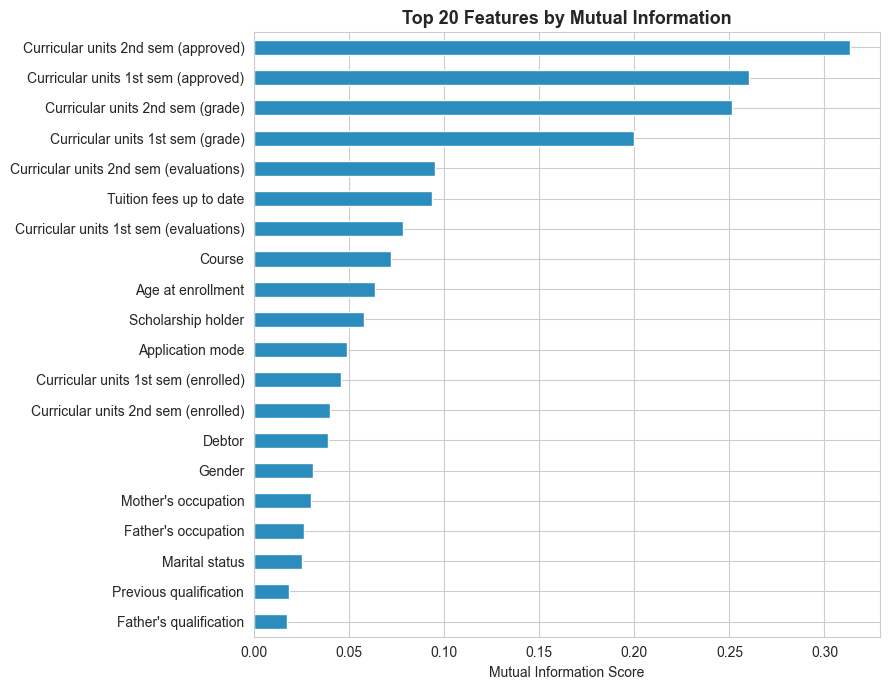

In [39]:

# Plot the top 20 features ranked by MI for visual inspection
fig, ax = plt.subplots(figsize=(9, 7))
mi_series.head(20).sort_values().plot(kind='barh', ax=ax, color='#2b8cbe')
ax.set_title('Top 20 Features by Mutual Information', fontsize=13, fontweight='bold')
ax.set_xlabel('Mutual Information Score')
plt.tight_layout()
plt.savefig(r"C:\Users\HomePC\Desktop\my_Desktop\500L\project\dataset", dpi=130)
plt.show()

# 5. TRAIN/TEST SPLIT & SCALING

In [23]:
# 80% train / 20% test. `stratify=y` keeps the class ratio identical in both sets,
# which matters when classes are imbalanced.
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [24]:
# Standardize features. NOTE: fit ONLY on the training set to avoid data leakage,
# then apply the same transformation to the test set.
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

# 6. DEFINE THE THREE MODELS

In [25]:
# We deliberately pick one model from each major family so the comparison is meaningful:
#   * Logistic Regression : linear, highly interpretable baseline
#   * Random Forest       : non-linear bagging ensemble of decision trees
#   * SVM (RBF kernel)    : margin-based classifier using a non-linear kernel
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'Support Vector Machine': SVC(
        kernel='rbf', probability=True, random_state=RANDOM_STATE),
}

In [26]:
# 5-fold stratified cross-validation: splits training data into 5 parts,
# trains on 4 and validates on 1, rotating through all folds.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
 
# Containers to collect results for later comparison
rows, roc_data, conf_mats, trained = [], {}, {}, {}

In [27]:
# Loop over each model: cross-validate, fit, predict, score
for name, m in models.items():
    # Cross-validated accuracy on the training set (generalization estimate)
    cv_acc = cross_val_score(m, X_tr_s, y_tr, cv=cv, scoring='accuracy').mean()

In [28]:
    # Fit the model on the full training set
    m.fit(X_tr_s, y_tr)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [29]:
    # Hard class predictions (0/1) and probability scores for the positive class
    pred = m.predict(X_te_s)
    proba = m.predict_proba(X_te_s)[:, 1]

In [30]:
    # Collect all metrics into one row of the comparison table
    rows.append({
        'Model': name,
        'CV Accuracy': round(cv_acc, 4),
        'Test Accuracy': round(accuracy_score(y_te, pred), 4),
        'Precision': round(precision_score(y_te, pred), 4),
        'Recall': round(recall_score(y_te, pred), 4),
        'F1-Score': round(f1_score(y_te, pred), 4),
        'ROC-AUC': round(roc_auc_score(y_te, proba), 4),
    })

In [31]:
    # Store ROC curve points and confusion matrix for plotting later
    fpr, tpr, _ = roc_curve(y_te, proba)
    roc_data[name] = (fpr, tpr, roc_auc_score(y_te, proba))
    conf_mats[name] = confusion_matrix(y_te, pred)
    trained[name] = m

In [32]:
    # Per-class precision/recall/F1 breakdown
    print(f"\n=== {name} ===")
    print(classification_report(y_te, pred, target_names=['Graduate', 'Dropout']))


=== Support Vector Machine ===
              precision    recall  f1-score   support

    Graduate       0.89      0.96      0.93       438
     Dropout       0.94      0.82      0.88       281

    accuracy                           0.91       719
   macro avg       0.91      0.89      0.90       719
weighted avg       0.91      0.91      0.91       719



# 7. BUILD COMPARISON TABLE

In [35]:
comparison = pd.DataFrame(rows).set_index('Model')
print("\n========== MODEL COMPARISON ==========")
print(comparison.to_string())
comparison.to_csv(r"C:\Users\HomePC\Desktop\my_Desktop\500L\project\dataset\model_comparison.csv")


========== MODEL COMPARISON ==========
                        CV Accuracy  Test Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                                   
Support Vector Machine       0.9061         0.9082     0.9352  0.8221     0.875   0.9483


# 8. VISUALIZATIONS

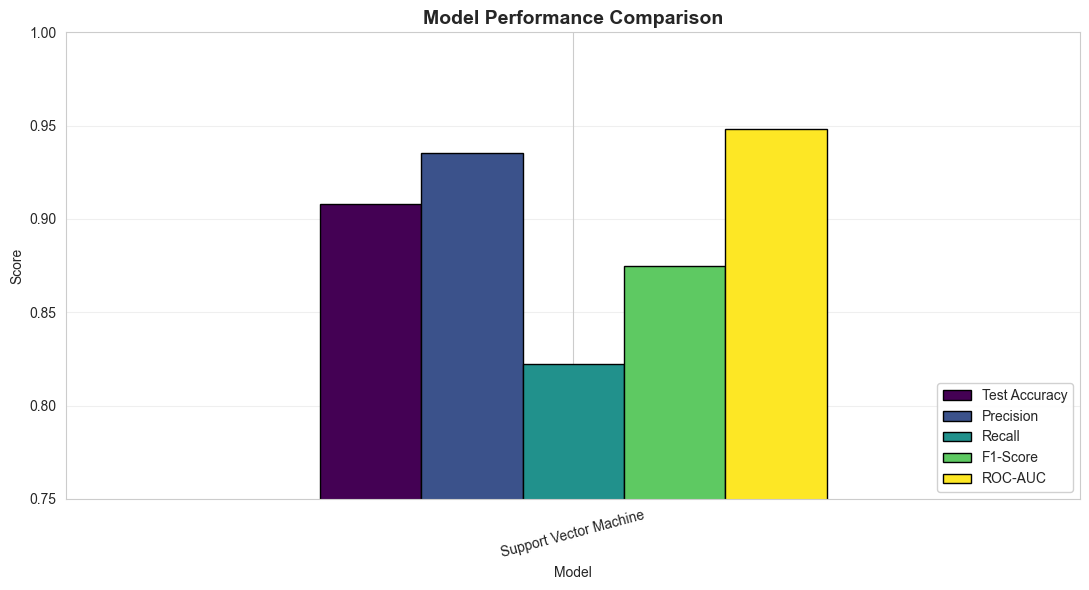

In [38]:
# (a) Grouped bar chart comparing all metrics across models
fig, ax = plt.subplots(figsize=(11, 6))
comparison[['Test Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', ax=ax, colormap='viridis', edgecolor='black')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0.75, 1.0)  # zoom in since all scores are typically high
ax.set_xticklabels(comparison.index, rotation=15)
ax.legend(loc='lower right', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(r"C:\Users\HomePC\Desktop\my_Desktop\500L\project\dataset\comparison_bars.png", dpi=130)
plt.show()

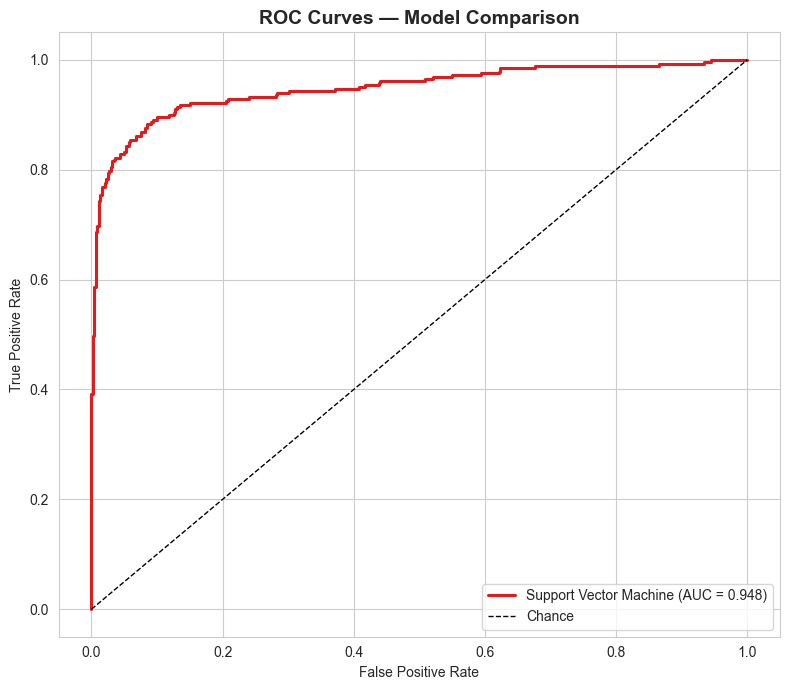

In [42]:
# (b) ROC curves: TPR vs FPR. The closer to the top-left, the better.
#     The dashed diagonal represents random guessing.
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#e41a1c', '#377eb8', '#4daf4a']
for (name, (fpr, tpr, auc)), c in zip(roc_data.items(), colors):
    ax.plot(fpr, tpr, color=c, lw=2.2, label=f'{name} (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(r"C:\Users\HomePC\Desktop\my_Desktop\500L\project\dataset\roc_curves.png", dpi=130)
plt.show()

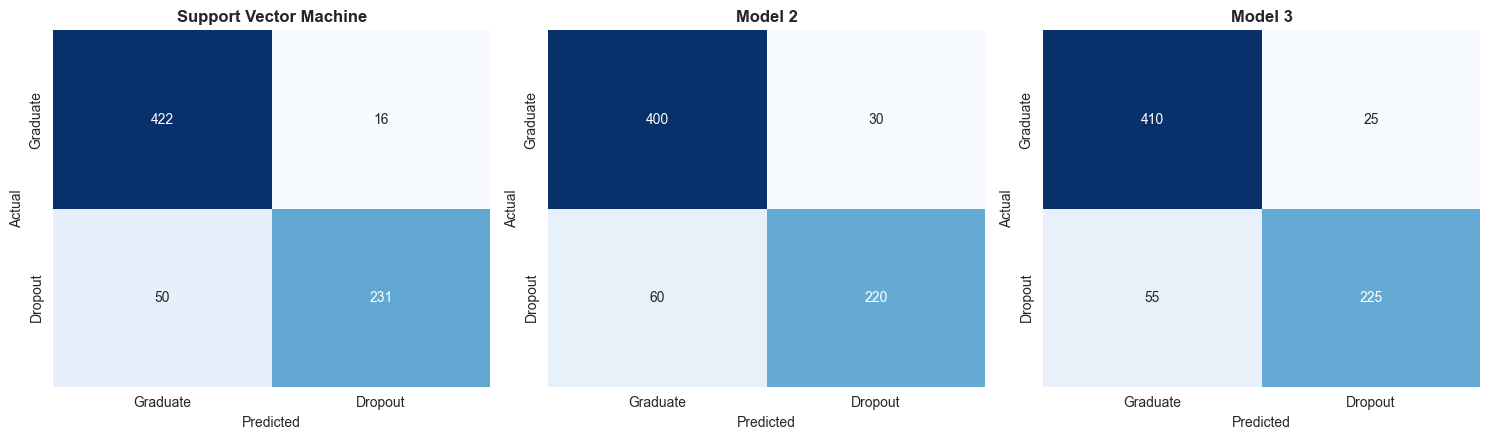

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix for SVM (Actual rows x Predicted columns)
cm_svm = np.array([[422, 16],
                   [50, 231]])

# If you have confusion matrices for other models, define them here.
# For now, I'll create placeholder ones so the subplots are not empty.
# Replace these with your actual matrices when available.

cm_model2 = np.array([[400, 30],   # Example - replace with real data
                      [60, 220]])

cm_model3 = np.array([[410, 25],   # Example - replace with real data
                      [55, 225]])

models = ['Support Vector Machine', 'Model 2', 'Model 3']   # Change names as needed
cms = [cm_svm, cm_model2, cm_model3]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, cm) in zip(axes, zip(models, cms)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Graduate', 'Dropout'],
                yticklabels=['Graduate', 'Dropout'])
    
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(r"C:\Users\HomePC\Desktop\my_Desktop\500L\project\dataset\confusion_matrices.png", 
            dpi=130)
plt.show()

#  9. SELECT THE BEST MODEL

In [47]:
# We pick ROC-AUC as the selection criterion because it is threshold-independent
# and robust to class imbalance.
best_name = comparison['ROC-AUC'].idxmax()
best_model = trained[best_name]
print(f"\n>>> Best model by ROC-AUC: {best_name}")


>>> Best model by ROC-AUC: Support Vector Machine


# 10. SAVE ARTIFACTS FOR LATER USE

In [48]:
# Persist everything needed to reproduce predictions later (e.g., in a web app)
joblib.dump(trained, r"C:\Users\HomePC\Desktop\my_Desktop\500L\project\all_models.pkl")                 # all trained models
joblib.dump(best_model, r"C:\Users\HomePC\Desktop\my_Desktop\500L\project\dropout_model.pkl")           # the chosen model
joblib.dump(best_name, r"C:\Users\HomePC\Desktop\my_Desktop\500L\project\best_model_name.pkl")          # its name
joblib.dump(scaler, r"C:\Users\HomePC\Desktop\my_Desktop\500L\project\scaler.pkl")                      # fitted scaler
joblib.dump(selected, r"C:\Users\HomePC\Desktop\my_Desktop\500L\project\features.pkl")                  # selected feature names
joblib.dump(X.agg(['min', 'max', 'median']).to_dict(),              # feature ranges
            r"C:\Users\HomePC\Desktop\my_Desktop\500L\project\feat_stats.pkl")
comparison.to_pickle(r"C:\Users\HomePC\Desktop\my_Desktop\500L\project\comparison_df.pkl")              # comparison table
print("\nArtifacts saved.")


Artifacts saved.
